In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Customer Churn.csv")
df
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Replacing Blanks with 0 as tenure is 0 and no totals charges are Recorded

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = df["TotalCharges"].astype("float")


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.duplicated().sum() # Checking for duplicate values in the dataset

np.int64(0)

### Converted 0 & 1 values of Senior Citizen into Yes/No TO make it Easier to Understand

In [9]:
def convertor(value):
    if value == 1:
        return "Yes"
    else:
        return "No"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(convertor)

Text(0.5, 1.0, 'Count of Customers By Churned')

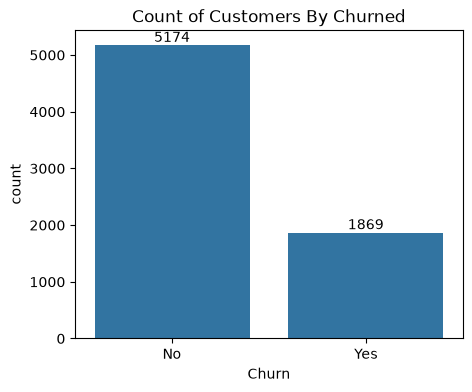

In [10]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x="Churn", data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers By Churned")


### From the Given Pie Chart we Can Conclude That 26.54% of our Customers Have Churned Out.

Text(0.5, 1.0, 'Percentage of Customers By Churned')

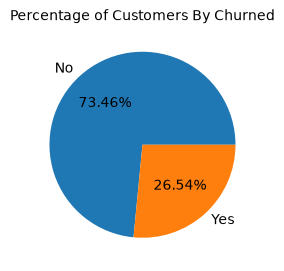

In [11]:
plt.figure(figsize=(3,4))
gb = df.groupby('Churn').agg({'Churn':"count"})
plt.pie(gb['Churn'], labels=gb.index, autopct='%1.2f%%') 
plt.title("Percentage of Customers By Churned", fontsize=10)

Text(0.5, 1.0, 'Churned By Gender')

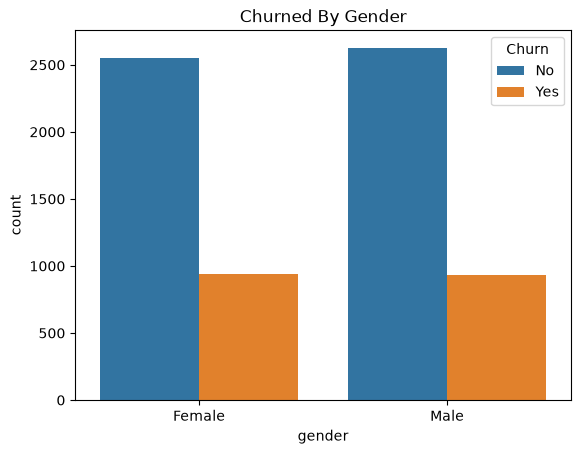

In [14]:
sns.countplot(x="gender", data=df, hue = 'Churn')
plt.title("Churned By Gender")


(0.0, 100.0)

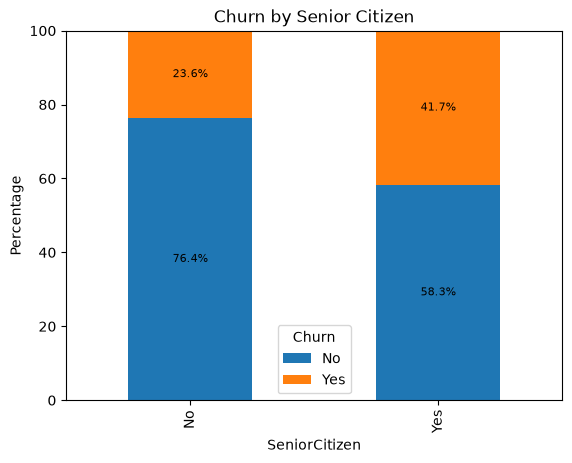

In [18]:
# Percentage table
pct = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

# Plot
ax = pct.plot(kind="bar", stacked=True)

# Add percentage labels
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", fontsize=8)

plt.title("Churn by Senior Citizen")
plt.ylabel("Percentage")
plt.ylim(0, 100)

Text(0.5, 1.0, 'Count of Customers By Senior Citizen')

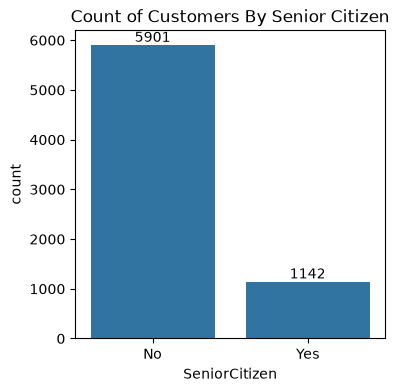

In [25]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x = "SeniorCitizen", data = df)
ax .bar_label(ax.containers[0])
plt.title("Count of Customers By Senior Citizen")


#### People Who have used our Services For a long Time Have Stayed and people Who have used our Services 1 & 2 Months have Churned

Text(0.5, 1.0, 'Distribution of Tenure by Churned Customers')

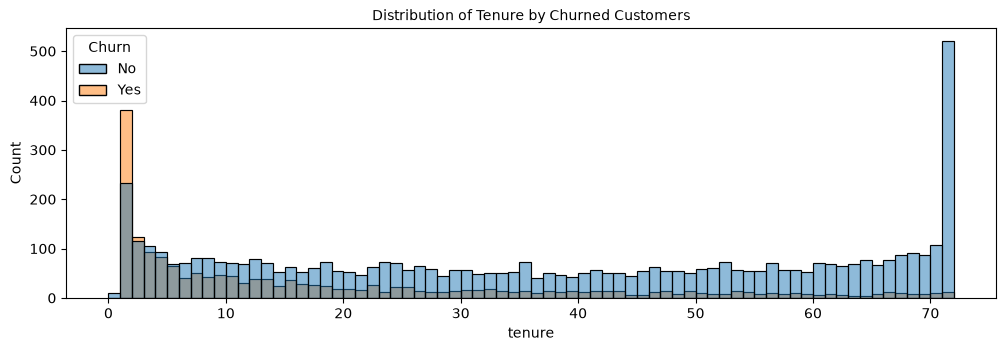

In [41]:
plt.figure(figsize=(12,3.5))
sns.histplot(x = 'tenure', data = df, bins = 72, hue = 'Churn')
plt.title('Distribution of Tenure by Churned Customers', fontsize=10)

#### People Who have Month to Month Contract are Likely to Churn then from those who have 1 or 2 years or contract

Text(0.5, 1.0, 'Count of Customers By Contract Type')

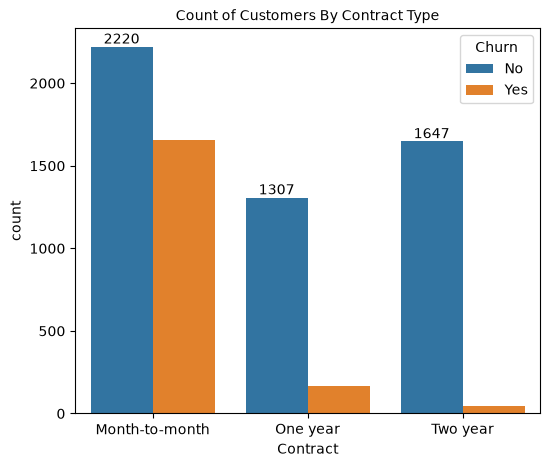

In [ ]:
plt.figure(figsize=(6,5))
ax = sns.countplot( x = 'Contract', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customers By Contract Type", fontsize=10)


In [ ]:
df.columns.values # Gives the list of all the columns in the dataset

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

#### Customers with Online Security and Tech Support services show significantly lower churn, while those without these services are much more likely to leave. Additionally, customers using Fiber Optic Internet exhibit the highest churn rate, whereas Phone Service, Streaming TV, and Streaming Movies have a relatively smaller impact on customer churn.

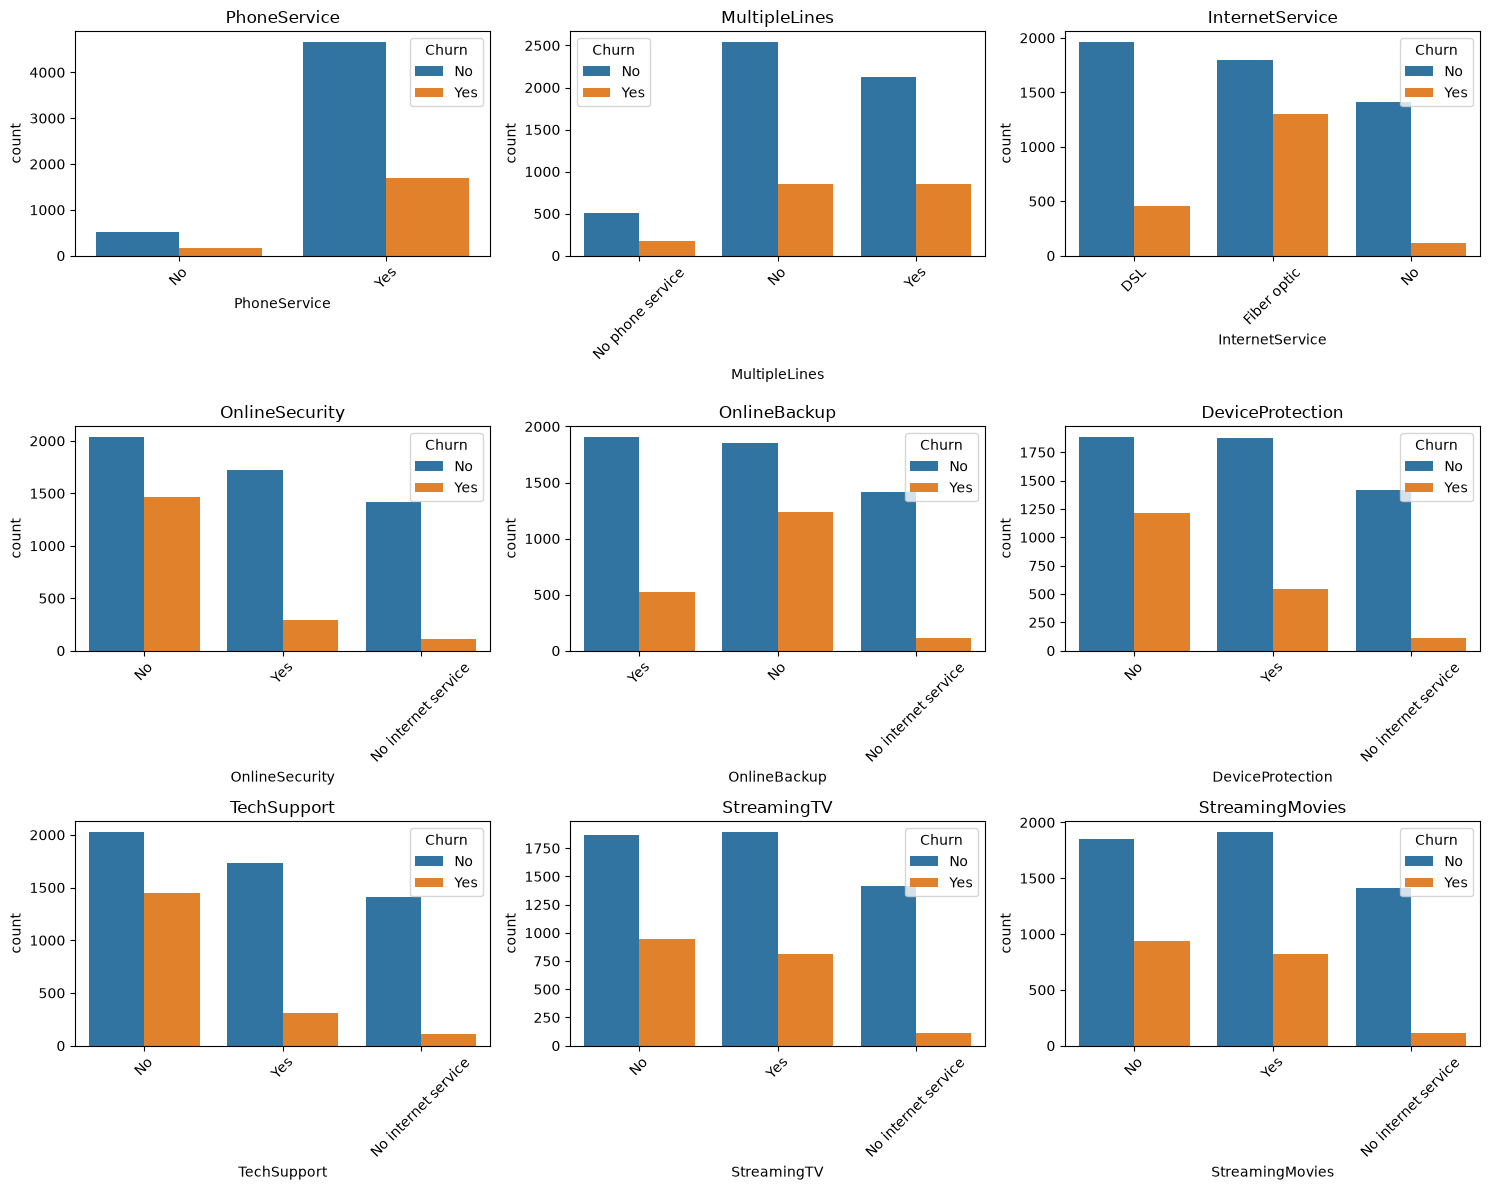

In [48]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.countplot(data=df, x=col, ax=ax, hue=df['Churn'])
  
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

#### Customer is likely to churn when he is using eletronic check as Payment Method.

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

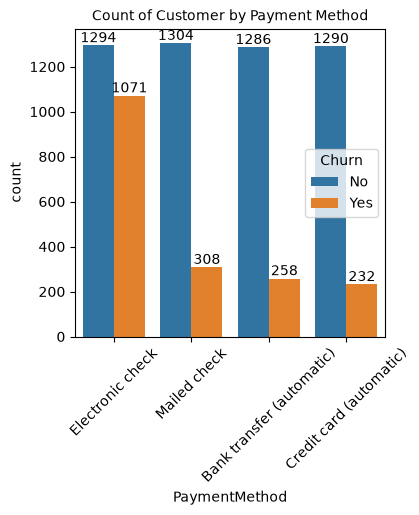

In [54]:
plt.figure(figsize=(4,4))
ax = sns.countplot( x = 'PaymentMethod', data = df, hue ='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customer by Payment Method", fontsize=10)
plt.xticks(rotation=45)

